## **Project**

# **E-Commerce Conversion & Customer Behavior Analysis**

E-commerce businesses generate large amounts of customer interaction and transaction data. However, high website traffic does not necessarily result in high sales. Customers may visit products, browse multiple pages, spend considerable time on the website, or add products to their cart without completing a purchase.

This project analyzes e-commerce customer behavior, website engagement, product characteristics, pricing, discounts, marketing channels, and payment methods to understand the factors associated with purchase conversion and cart abandonment.

The analysis uses Python, Pandas, NumPy, Matplotlib, and Seaborn to perform data cleaning, exploratory data analysis, hypothesis-based analysis, visualization, and business interpretation.

The objective is not only to identify patterns in the data but also to convert those patterns into actionable business recommendations for improving conversion rates, reducing cart abandonment, and understanding customer behavior.

# **02. Business Problem**
# **Problem Statement**

An e-commerce business receives a large number of customer visits, but not every visitor completes a purchase. Some customers browse products without purchasing, while others add products to their cart and abandon the purchase.

The business needs to understand what factors are associated with customer conversion and abandonment so that it can improve the customer journey and make better decisions regarding pricing, discounts, marketing channels, and payment options.

This project investigates customer behavior and transaction data to identify the major patterns associated with:

Purchase conversion
Cart abandonment
Customer engagement
Product pricing
Discounts
Marketing channels
Payment methods
Product categories

The findings will be translated into practical recommendations that an e-commerce business could use to improve its conversion performance.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/Ecommerce.csv")

In [ ]:
df.head()

,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
0,1803,0,28-11-2024,2,1,2,894,6,651.57,1,...,1,0,1,28,11,3,0,Long,0.000000,209
1,7964,1,25-09-2024,2,0,4,844,2,945.27,4,...,1,0,2,25,9,2,0,Long,0.000000,213
2,6890,2,31-05-2024,1,1,0,865,0,400.44,4,...,1,0,2,31,5,4,1,Short,0.000000,10
3,4949,3,30-01-2024,1,0,2,851,3,1268.54,2,...,10,4,1,30,1,1,3,Very Long,0.305504,46
4,4896,4,25-02-2024,1,1,5,794,3,880.81,3,...,1,0,1,25,2,6,3,Very Short,0.000000,118


In [ ]:
df.shape

(25000, 29)

In [ ]:
df.columns.tolist()

['customer_id',
 'session_id',
 'visit_date',
 'device_type',
 'user_type',
 'marketing_channel',
 'product_id',
 'product_category',
 'unit_price',
 'quantity',
 'discount_percent',
 'discount_amount',
 'revenue',
 'pages_viewed',
 'time_on_site_sec',
 'added_to_cart',
 'purchased',
 'cart_abandoned',
 'rating',
 'review_text',
 'review_helpful_votes',
 'payment_method',
 'visit_day',
 'visit_month',
 'visit_weekday',
 'visit_season',
 'session_duration_bucket',
 'revenue_normalized',
 'location']

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plotting style
sns.set_theme(style="whitegrid")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              25000 non-null  int64  
 1   session_id               25000 non-null  int64  
 2   visit_date               25000 non-null  object 
 3   device_type              25000 non-null  int64  
 4   user_type                25000 non-null  int64  
 5   marketing_channel        25000 non-null  int64  
 6   product_id               25000 non-null  int64  
 7   product_category         25000 non-null  int64  
 8   unit_price               25000 non-null  float64
 9   quantity                 25000 non-null  int64  
 10  discount_percent         25000 non-null  int64  
 11  discount_amount          25000 non-null  float64
 12  revenue                  25000 non-null  float64
 13  pages_viewed             25000 non-null  int64  
 14  time_on_site_sec      

In [ ]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df.describe()

,customer_id,session_id,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,discount_percent,discount_amount,revenue,pages_viewed,time_on_site_sec,added_to_cart,purchased,cart_abandoned,rating,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,revenue_normalized,location
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.00000,25000.00000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000
mean,5479.930600,12499.500000,0.705040,0.551280,2.514040,449.107000,3.495240,782.319010,2.489040,8.99880,174.997669,404.646762,12.535840,903.262920,0.64468,0.224640,0.420040,3.94800,1.67488,5.52080,2.483160,15.714520,6.510520,2.980800,1.504400,0.051290,111.70692
std,2593.544596,7217.022701,0.639543,0.497373,1.704934,259.513787,2.285053,476.612168,1.114563,9.26364,269.005411,1022.391774,6.929762,518.676202,0.47862,0.417353,0.493575,0.54047,1.98673,12.33629,1.709501,8.796338,3.457925,1.992554,1.117475,0.129591,65.07079
min,1000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.050000,1.000000,0.00000,0.000000,0.000000,1.000000,10.000000,0.00000,0.000000,0.000000,1.00000,0.00000,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,3234.000000,6249.750000,0.000000,0.000000,1.000000,225.000000,2.000000,395.222500,1.000000,0.00000,0.000000,0.000000,7.000000,453.000000,0.00000,0.000000,0.000000,4.00000,1.00000,0.00000,1.000000,8.000000,3.000000,1.000000,1.000000,0.000000,55.00000
50%,5482.000000,12499.500000,1.000000,1.000000,2.000000,448.000000,4.000000,691.725000,2.000000,10.00000,65.815000,0.000000,13.000000,903.000000,1.00000,0.000000,0.000000,4.00000,1.00000,0.00000,2.000000,16.000000,7.000000,3.000000,2.000000,0.000000,111.00000
75%,7715.000000,18749.250000,1.000000,1.000000,4.000000,675.000000,5.000000,1096.842500,3.000000,15.00000,240.355000,0.000000,19.000000,1355.000000,1.00000,0.000000,1.000000,4.00000,1.00000,0.00000,4.000000,23.000000,10.000000,5.000000,3.000000,0.000000,169.00000
max,9998.000000,24999.000000,2.000000,1.000000,5.000000,898.000000,7.000000,1999.830000,4.000000,30.00000,2388.260000,7889.360000,24.000000,1799.000000,1.00000,1.000000,1.000000,5.00000,10.00000,49.00000,5.000000,31.000000,12.000000,6.000000,3.000000,1.000000,224.00000


In [ ]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))


--- visit_date ---
visit_date
20-09-2024    91
28-05-2024    91
11-10-2024    90
07-05-2024    89
28-03-2024    88
07-04-2024    88
09-02-2024    87
01-11-2024    86
24-04-2024    86
22-08-2024    85
Name: count, dtype: int64

--- session_duration_bucket ---
session_duration_bucket
Very Short    6270
Long          6254
Very Long     6240
Short         6236
Name: count, dtype: int64


In [ ]:
for col in ['added_to_cart', 'purchased', 'cart_abandoned']:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


added_to_cart:
added_to_cart
1    16117
0     8883
Name: count, dtype: int64

purchased:
purchased
0    19384
1     5616
Name: count, dtype: int64

cart_abandoned:
cart_abandoned
0    14499
1    10501
Name: count, dtype: int64


In [ ]:
df['visit_date'] = pd.to_datetime(df['visit_date'])

print(df['visit_date'].dtype)

datetime64[ns]


/tmp/ipykernel_1280/2033680118.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['visit_date'] = pd.to_datetime(df['visit_date'])


In [ ]:
print("Minimum date:", df['visit_date'].min())
print("Maximum date:", df['visit_date'].max())

Minimum date: 2024-01-01 00:00:00
Maximum date: 2024-12-30 00:00:00


In [ ]:
df.dtypes

,0
customer_id,int64
session_id,int64
visit_date,datetime64[ns]
device_type,int64
user_type,int64
marketing_channel,int64
product_id,int64
product_category,int64
unit_price,float64
quantity,int64


In [ ]:
print("Total sessions:", len(df))

print("\nAdded to cart:")
print(df['added_to_cart'].value_counts())

print("\nPurchased:")
print(df['purchased'].value_counts())

print("\nCart abandoned:")
print(df['cart_abandoned'].value_counts())

Total sessions: 25000

Added to cart:
added_to_cart
1    16117
0     8883
Name: count, dtype: int64

Purchased:
purchased
0    19384
1     5616
Name: count, dtype: int64

Cart abandoned:
cart_abandoned
0    14499
1    10501
Name: count, dtype: int64


In [ ]:
pd.crosstab(
    df['added_to_cart'],
    df['cart_abandoned']
)

cart_abandoned,0,1
added_to_cart,,
0,8883,0
1,5616,10501


In [ ]:
pd.crosstab(
    df['added_to_cart'],
    df['purchased']
)

purchased,0,1
added_to_cart,,
0,8883,0
1,10501,5616


In [ ]:
pd.crosstab(
    df['purchased'],
    df['payment_method'].isna()
)

payment_method,False
purchased,
0,19384
1,5616


In [ ]:
customer_sessions = df.groupby('customer_id')['session_id'].nunique()

print("Total unique customers:", customer_sessions.shape[0])
print("Customers with more than one session:", (customer_sessions > 1).sum())

Total unique customers: 8442
Customers with more than one session: 6918


In [ ]:
customer_purchases = df.groupby('customer_id')['purchased'].sum()

print("Customers with more than one purchase:",
      (customer_purchases > 1).sum())

Customers with more than one purchase: 1159


In [ ]:
categorical_cols_to_convert = [
    'device_type',
    'user_type',
    'marketing_channel',
    'product_category',
    'payment_method',
    'visit_day',
    'visit_month',
    'visit_weekday',
    'visit_season'
]

for col in categorical_cols_to_convert:
    df[col] = df[col].astype('category')

# Create new feature: discount_rate
df['discount_rate'] = df['discount_percent'] / 100

# Create new feature: total_price (unit_price * quantity)
df['total_price'] = df['unit_price'] * df['quantity']

print("Data cleaning and engineering complete. Here's a look at the updated data types and new features:")
print(df[categorical_cols_to_convert + ['discount_rate', 'total_price']].dtypes)


Data cleaning and engineering complete. Here's a look at the updated data types and new features:
device_type          category
user_type            category
marketing_channel    category
product_category     category
payment_method       category
visit_day            category
visit_month          category
visit_weekday        category
visit_season         category
discount_rate         float64
total_price           float64
dtype: object


Feature Engineering

In [ ]:
df['conversion'] = df['purchased']

In [ ]:
df['customer_purchase_count'] = df.groupby('customer_id')['purchased'].transform('sum')

In [ ]:
df[['customer_id', 'purchased', 'customer_purchase_count']].head(10)

,customer_id,purchased,customer_purchase_count
0,1803,0,1
1,7964,0,2
2,6890,0,0
3,4949,1,2
4,4896,0,1
5,8726,0,0
6,1773,1,4
7,7275,0,1
8,2813,0,1
9,1847,0,0


In [ ]:
df['repeat_customer'] = (df['customer_purchase_count'] > 1).astype(int)

In [ ]:
df['repeat_customer'].value_counts()

,count
repeat_customer,
0,19943
1,5057


In [ ]:
df['unit_price'].describe()

,unit_price
count,25000.000000
mean,782.319010
std,476.612168
min,50.050000
25%,395.222500
50%,691.725000
75%,1096.842500
max,1999.830000


In [ ]:
df['engagement_group'] = pd.qcut(
    df['pages_viewed'],
    q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

In [ ]:
df['engagement_group'].value_counts()

,count
engagement_group,
Low,7227
Medium-High,6294
Medium-Low,6241
High,5238


In [ ]:
df['discount_percent'].describe()

,discount_percent
count,25000.00000
mean,8.99880
std,9.26364
min,0.00000
25%,0.00000
50%,10.00000
75%,15.00000
max,30.00000


In [ ]:
print("Total Sessions:", len(df))
print("Unique Customers:", df['customer_id'].nunique())
print("Total Revenue:", df['revenue'].sum())
print("Total Purchases:", df['purchased'].sum())
print("Overall Conversion Rate:",
      df['purchased'].mean() * 100)
print("Cart Abandonments:", df['cart_abandoned'].sum())

Total Sessions: 25000
Unique Customers: 8442
Total Revenue: 10116169.06
Total Purchases: 5616
Overall Conversion Rate: 22.464000000000002
Cart Abandonments: 10501


In [ ]:
category_sales = (
    df.groupby('product_category', observed=True)['revenue']
    .sum()
    .sort_values(ascending=False)
)

category_sales

,revenue
product_category,
2,2037576.79
6,1930885.22
5,1729167.16
3,1293649.90
7,1089617.52
0,880077.03
1,702788.87
4,452406.57


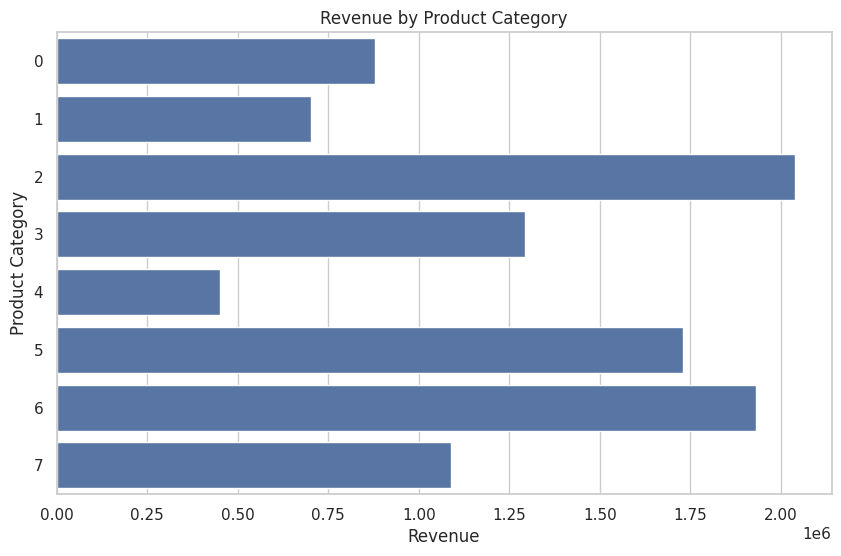

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title('Revenue by Product Category')
plt.xlabel('Revenue')
plt.ylabel('Product Category')
plt.show()

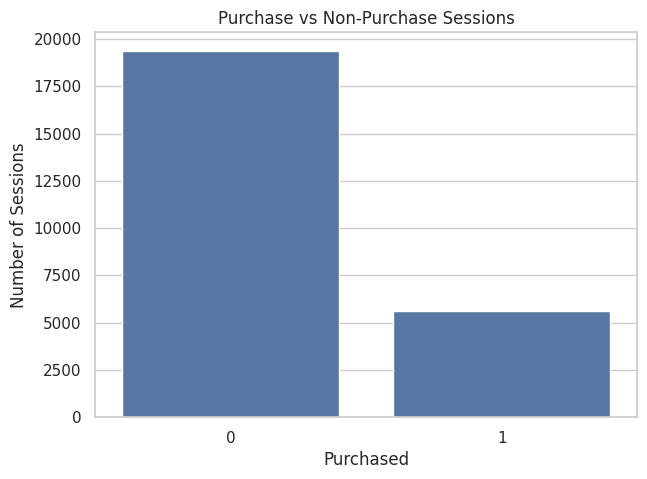

In [ ]:
purchase_counts = df['purchased'].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=purchase_counts.index,
    y=purchase_counts.values
)

plt.title('Purchase vs Non-Purchase Sessions')
plt.xlabel('Purchased')
plt.ylabel('Number of Sessions')
plt.show()

In [ ]:
channel_conversion = (
    df.groupby('marketing_channel', observed=True)['purchased']
    .mean()
    .sort_values(ascending=False) * 100
)

channel_conversion

,purchased
marketing_channel,
5,23.598405
0,22.717149
3,22.643343
1,22.124105
2,22.027564
4,21.659771


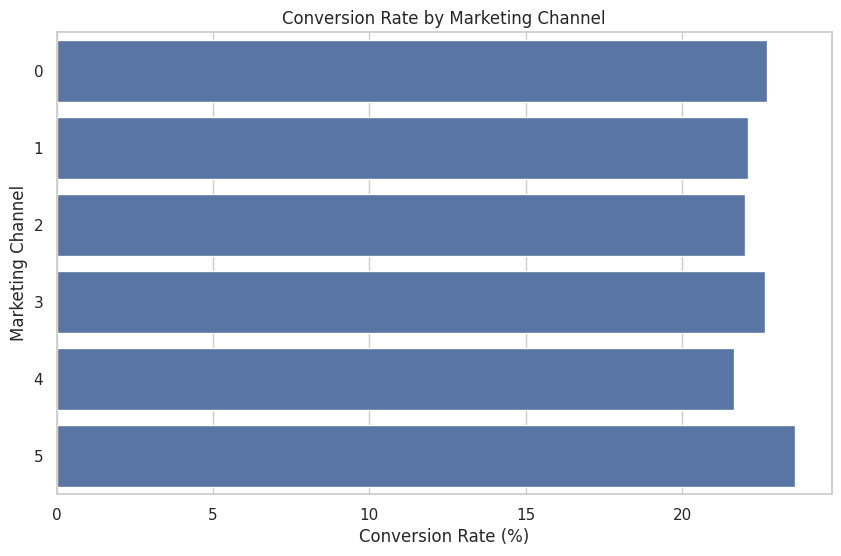

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=channel_conversion.values,
    y=channel_conversion.index
)

plt.title('Conversion Rate by Marketing Channel')
plt.xlabel('Conversion Rate (%)')
plt.ylabel('Marketing Channel')
plt.show()

In [ ]:
pages_purchase = (
    df.groupby('purchased')['pages_viewed']
    .mean()
)

pages_purchase

,pages_viewed
purchased,
0,12.512846
1,12.615207


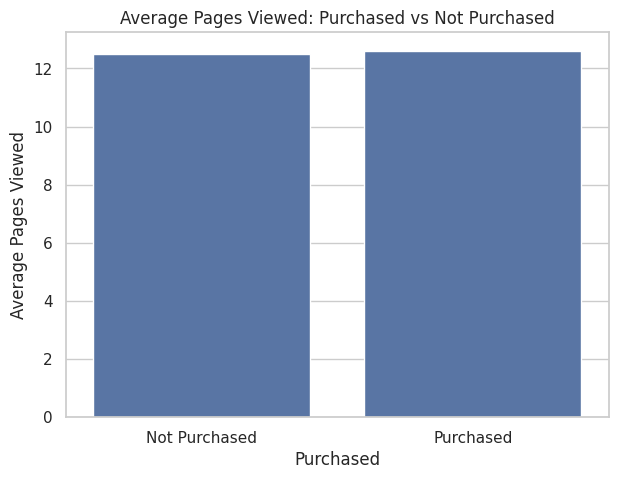

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=pages_purchase.index,
    y=pages_purchase.values
)

plt.title('Average Pages Viewed: Purchased vs Not Purchased')
plt.xlabel('Purchased')
plt.ylabel('Average Pages Viewed')

plt.xticks([0, 1], ['Not Purchased', 'Purchased'])

plt.show()

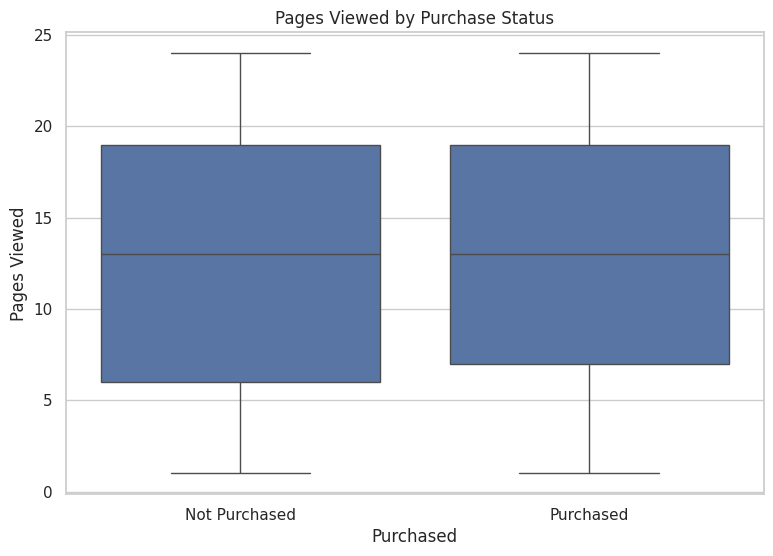

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='purchased',
    y='pages_viewed'
)

plt.title('Pages Viewed by Purchase Status')
plt.xlabel('Purchased')
plt.ylabel('Pages Viewed')

plt.xticks([0, 1], ['Not Purchased', 'Purchased'])

plt.show()

In [ ]:
time_purchase = (
    df.groupby('purchased')['time_on_site_sec']
    .mean()
)

time_purchase

,time_on_site_sec
purchased,
0,895.605809
1,929.691952


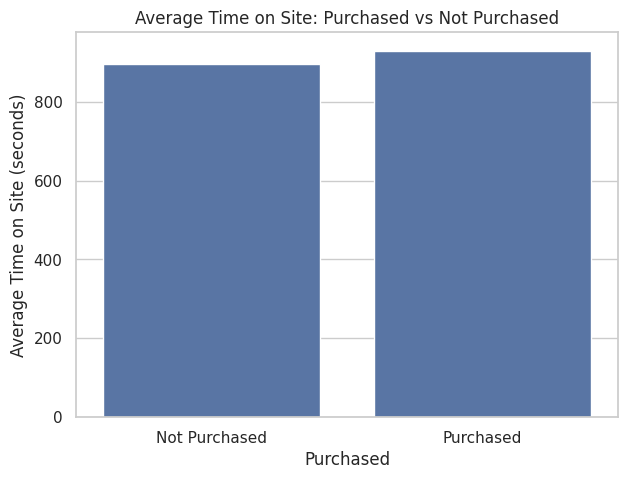

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=time_purchase.index,
    y=time_purchase.values
)

plt.title('Average Time on Site: Purchased vs Not Purchased')
plt.xlabel('Purchased')
plt.ylabel('Average Time on Site (seconds)')

plt.xticks([0, 1], ['Not Purchased', 'Purchased'])

plt.show()

In [ ]:
#calculating conversion rate
engagement_conversion = (
    df.groupby('engagement_group', observed=True)['purchased']
    .mean() * 100
)

engagement_conversion

,purchased
engagement_group,
Low,22.111526
Medium-Low,22.288095
Medium-High,22.910709
High,22.623139


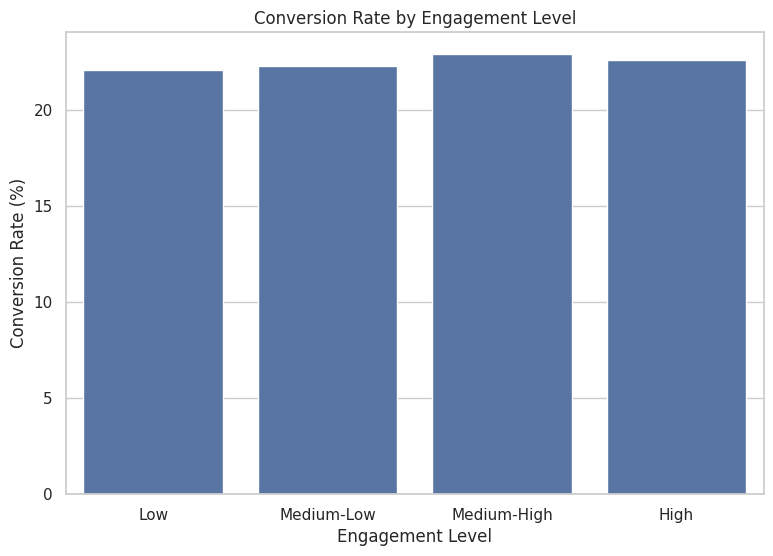

In [ ]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=engagement_conversion.index,
    y=engagement_conversion.values
)

plt.title('Conversion Rate by Engagement Level')
plt.xlabel('Engagement Level')
plt.ylabel('Conversion Rate (%)')

plt.show()

Observation:
Customers who purchased showed slightly higher levels of website engagement
in terms of pages viewed and time spent on the website compared with
non-purchasing customers. However, the difference was relatively small.

This suggests that higher engagement may be associated with purchase,
but engagement alone does not appear to be a strong determinant of
conversion in this dataset.

In [ ]:
cart_users = df[df['added_to_cart'] == 1]

abandonment_rate = (
    cart_users['cart_abandoned'].mean() * 100
)

conversion_after_cart = (
    cart_users['purchased'].mean() * 100
)

print("Customers who added to cart:", len(cart_users))
print("Cart abandonment rate:", round(abandonment_rate, 2), "%")
print("Purchase rate after adding to cart:", round(conversion_after_cart, 2), "%")

Customers who added to cart: 16117
Cart abandonment rate: 65.15 %
Purchase rate after adding to cart: 34.85 %


In [ ]:
cart_outcome = (
    cart_users['cart_abandoned']
    .value_counts()
    .rename(index={0: 'Purchased', 1: 'Abandoned'})
)

cart_outcome

,count
cart_abandoned,
Abandoned,10501
Purchased,5616


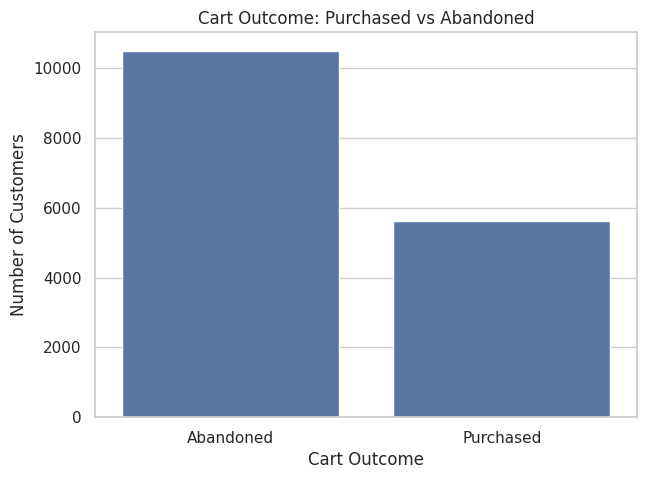

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=cart_outcome.index,
    y=cart_outcome.values
)

plt.title('Cart Outcome: Purchased vs Abandoned')
plt.xlabel('Cart Outcome')
plt.ylabel('Number of Customers')

plt.show()

In [ ]:
cart_outcome_pct = (
    cart_outcome / cart_outcome.sum() * 100
)

cart_outcome_pct

,count
cart_abandoned,
Abandoned,65.154805
Purchased,34.845195


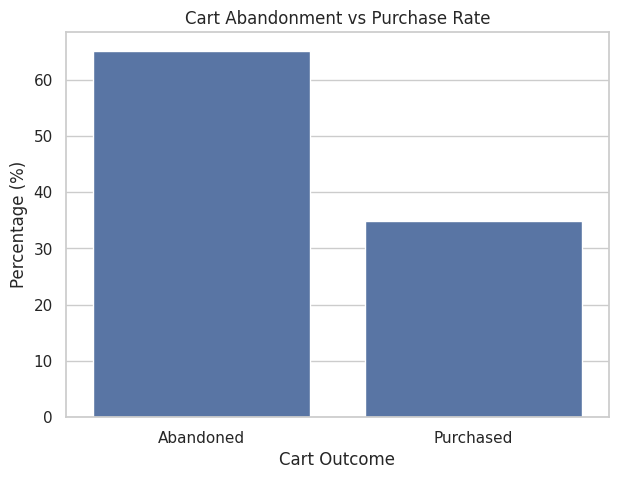

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=cart_outcome_pct.index,
    y=cart_outcome_pct.values
)

plt.title('Cart Abandonment vs Purchase Rate')
plt.xlabel('Cart Outcome')
plt.ylabel('Percentage (%)')

plt.show()

Observation:
Among the 16,117 sessions where customers added a product to their cart,
65.15% resulted in cart abandonment, while only 34.85% resulted in a
completed purchase.

This indicates that cart abandonment represents a substantial loss of
potential conversions in the e-commerce purchase funnel.

Business Interpretation:
The business should focus on reducing friction between cart addition
and checkout completion. Possible areas for investigation include
checkout experience, pricing at checkout, available payment methods,
discount attractiveness, and other factors that may influence the
decision to complete a purchase.

In [ ]:
print(df['unit_price'].describe())

count    25000.000000
mean       782.319010
std        476.612168
min         50.050000
25%        395.222500
50%        691.725000
75%       1096.842500
max       1999.830000
Name: unit_price, dtype: float64


In [ ]:
df['price_band'] = pd.qcut(
    df['unit_price'],
    q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

In [ ]:
df['price_band'].value_counts().sort_index()

,count
price_band,
Low,6250
Medium-Low,6250
Medium-High,6250
High,6250


In [ ]:
price_abandonment = (
    df[df['added_to_cart'] == 1]
    .groupby('price_band', observed=True)['cart_abandoned']
    .mean() * 100
)

price_abandonment

,cart_abandoned
price_band,
Low,65.001231
Medium-Low,65.732165
Medium-High,65.954237
High,63.963743


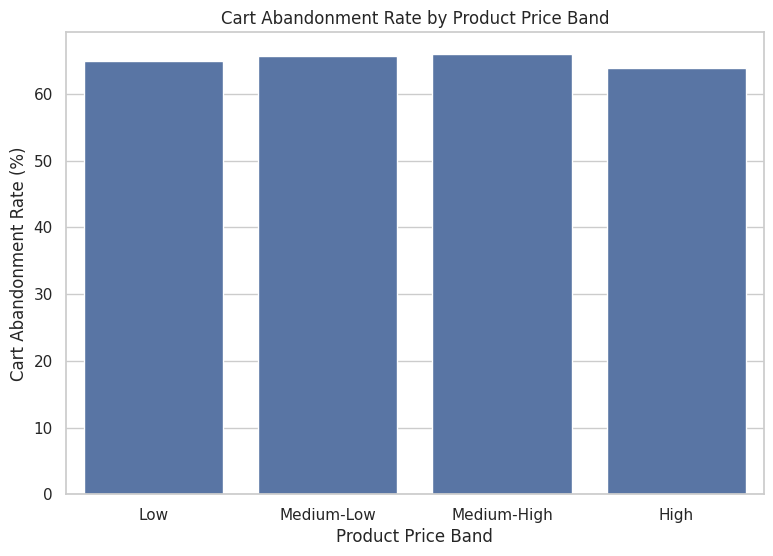

In [ ]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=price_abandonment.index,
    y=price_abandonment.values
)

plt.title('Cart Abandonment Rate by Product Price Band')
plt.xlabel('Product Price Band')
plt.ylabel('Cart Abandonment Rate (%)')

plt.show()

In [ ]:
df['unit_price'].describe()

,unit_price
count,25000.000000
mean,782.319010
std,476.612168
min,50.050000
25%,395.222500
50%,691.725000
75%,1096.842500
max,1999.830000


Observation:
Cart abandonment rates remain relatively similar across all four
product price bands, staying within a narrow range of approximately
64% to 66%. The highest-priced products do not show a substantially
higher abandonment rate than lower-priced products.

This suggests that product price alone does not have a strong
relationship with cart abandonment in this dataset.

Business Interpretation:
Since abandonment rates remain relatively stable across price bands,
the business should not assume that reducing product prices alone will
solve the cart abandonment problem. Other factors such as discounts,
payment methods, marketing channels, and the checkout experience may
be more relevant areas to investigate.

In [ ]:
print(df['discount_percent'].describe())

count    25000.00000
mean         8.99880
std          9.26364
min          0.00000
25%          0.00000
50%         10.00000
75%         15.00000
max         30.00000
Name: discount_percent, dtype: float64


In [ ]:
df['discount_band'] = pd.qcut(
    df['discount_percent'],
    q=4,
    duplicates='drop'
)

In [ ]:
df['discount_band'].value_counts().sort_index()

,count
discount_band,
"(-0.001, 10.0]",16265
"(10.0, 15.0]",3748
"(15.0, 30.0]",4987


In [ ]:
discount_conversion = (
    df.groupby('discount_band', observed=True)['purchased']
    .mean() * 100
)

discount_conversion

,purchased
discount_band,
"(-0.001, 10.0]",22.403935
"(10.0, 15.0]",22.705443
"(15.0, 30.0]",22.478444


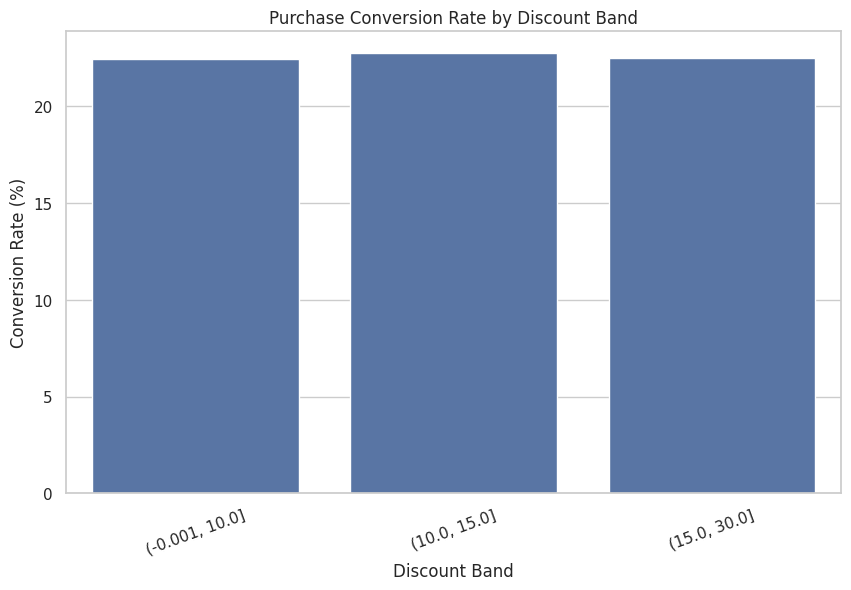

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=discount_conversion.index.astype(str),
    y=discount_conversion.values
)

plt.title('Purchase Conversion Rate by Discount Band')
plt.xlabel('Discount Band')
plt.ylabel('Conversion Rate (%)')

plt.xticks(rotation=20)

plt.show()

Observation:
Purchase conversion rates remain very similar across the different
discount bands. The conversion rate is 22.40% for discounts up to 10%,
22.71% for discounts between 10% and 15%, and 22.48% for discounts
above 15%.

The differences are very small, suggesting that discount percentage
alone does not have a strong relationship with purchase conversion
in this dataset.

Business Interpretation:
The business should not assume that increasing discounts will
automatically lead to substantially higher conversion. Larger discounts
may reduce margins without producing a meaningful improvement in
conversion. Discounts should therefore be evaluated alongside other
customer and product factors.

In [ ]:
purchase_df = df[df['purchased'] == 1].copy()

In [ ]:
customer_rating = (
    purchase_df
    .groupby('customer_id')
    .agg(
        avg_rating=('rating', 'mean'),
        purchase_count=('purchased', 'sum')
    )
    .reset_index()
)

In [ ]:
customer_rating['repeat_customer'] = (
    customer_rating['purchase_count'] > 1
).astype(int)

In [ ]:
customer_rating.head()

,customer_id,avg_rating,purchase_count,repeat_customer
0,1000,3.000000,1,0
1,1003,5.000000,1,0
2,1008,4.000000,1,0
3,1009,4.333333,3,1
4,1014,5.000000,1,0


In [ ]:
customer_rating['repeat_customer'].value_counts()

,count
repeat_customer,
0,3017
1,1159


In [ ]:
customer_rating['rating_band'] = pd.cut(
    customer_rating['avg_rating'],
    bins=[0, 2, 3, 4, 5],
    labels=['Low', 'Average', 'Good', 'Excellent'],
    include_lowest=True
)

In [ ]:
rating_repeat = (
    customer_rating
    .groupby('rating_band', observed=True)['repeat_customer']
    .mean() * 100
)

rating_repeat

,repeat_customer
rating_band,
Low,9.014675
Average,27.078385
Good,32.789969
Excellent,28.922345


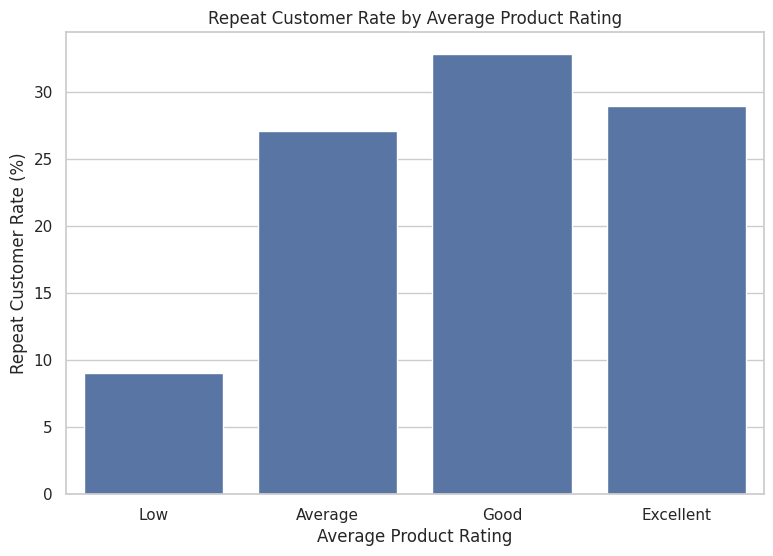

In [ ]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=rating_repeat.index,
    y=rating_repeat.values
)

plt.title('Repeat Customer Rate by Average Product Rating')
plt.xlabel('Average Product Rating')
plt.ylabel('Repeat Customer Rate (%)')

plt.show()

In [ ]:
rating_customer_counts = (
    customer_rating['rating_band']
    .value_counts()
    .sort_index()
)

rating_customer_counts

,count
rating_band,
Low,477
Average,842
Good,1595
Excellent,1262


In [ ]:
from scipy.stats import chi2_contingency

rating_table = pd.crosstab(
    customer_rating['rating_band'],
    customer_rating['repeat_customer']
)

chi2, p_value, dof, expected = chi2_contingency(rating_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 104.7635275517117
p-value: 1.469000172722607e-22


Observation:
Repeat-customer rates differ substantially across product rating bands.
The repeat-customer rate is lowest among customers with low-rated
products (9.01%) and highest among customers in the good-rating group
(32.79%). The excellent-rating group has a repeat-customer rate of
28.92%.

A chi-square test of independence produced a chi-square statistic of
104.76 with a p-value of approximately 1.47 × 10^-22, indicating a
statistically significant association between rating band and
repeat-customer status in this dataset.

Business Interpretation:
Product ratings are associated with repeat-customer behavior in this
dataset. The business should therefore monitor product quality and
customer feedback as part of its retention strategy. Products receiving
lower ratings may require investigation to identify quality, delivery,
or customer-experience issues.

,sessions,purchases,conversion_rate
marketing_channel,,,
5,4263,1006,23.598405
0,4041,918,22.717149
3,4116,932,22.643343
1,4190,927,22.124105
2,4281,943,22.027564
4,4109,890,21.659771


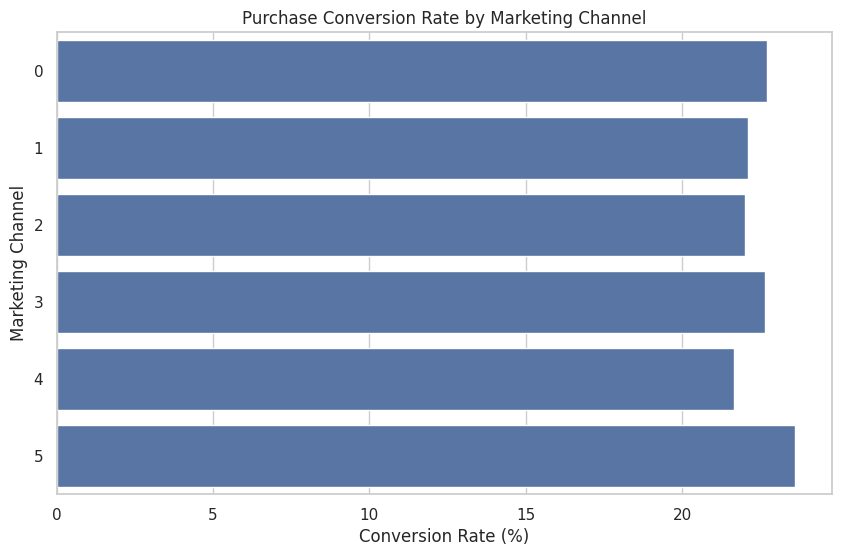

In [ ]:
# H6: Marketing Channel vs Conversion

channel_analysis = (
    df.groupby('marketing_channel', observed=True)
      .agg(
          sessions=('session_id', 'count'),
          purchases=('purchased', 'sum'),
          conversion_rate=('purchased', 'mean')
      )
)

channel_analysis['conversion_rate'] *= 100

display(channel_analysis.sort_values('conversion_rate', ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=channel_analysis.reset_index(),
    x='conversion_rate',
    y='marketing_channel'
)

plt.title('Purchase Conversion Rate by Marketing Channel')
plt.xlabel('Conversion Rate (%)')
plt.ylabel('Marketing Channel')
plt.show()

Observation:
Purchase conversion rates vary across marketing channels, ranging
from approximately 21.66% to 23.60%. Although some channels show
slightly higher conversion rates than others, the overall difference
is relatively small.

Therefore, marketing channel appears to have only a modest association
with purchase conversion in this dataset.

Business Interpretation:
Marketing channels should be evaluated not only by conversion rate
but also by traffic volume and acquisition cost. Since the conversion
rates are relatively close, the business should consider the complete
performance of each channel rather than selecting a channel based only
on its conversion rate.

In [ ]:
# Overall project KPIs

total_sessions = len(df)
unique_customers = df['customer_id'].nunique()
total_purchases = df['purchased'].sum()
conversion_rate = df['purchased'].mean() * 100
cart_additions = df['added_to_cart'].sum()
cart_abandonment_rate = (
    df.loc[df['added_to_cart'] == 1, 'cart_abandoned'].mean() * 100
)
total_revenue = df['revenue'].sum()

print(f"Total Sessions: {total_sessions:,}")
print(f"Unique Customers: {unique_customers:,}")
print(f"Total Purchases: {total_purchases:,}")
print(f"Overall Conversion Rate: {conversion_rate:.2f}%")
print(f"Cart Additions: {cart_additions:,}")
print(f"Cart Abandonment Rate: {cart_abandonment_rate:.2f}%")
print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Sessions: 25,000
Unique Customers: 8,442
Total Purchases: 5,616
Overall Conversion Rate: 22.46%
Cart Additions: 16,117
Cart Abandonment Rate: 65.15%
Total Revenue: ₹10,116,169.06


##  Overall Findings

- The dataset contains 25,000 e-commerce sessions and 8,442 unique customers.
- 16,117 sessions resulted in a product being added to the cart.
- Among cart additions, 65.15% were abandoned and 34.85% resulted in purchases.
- Customer engagement showed only a small difference between purchasing and non-purchasing sessions.
- Product price bands showed relatively similar cart abandonment rates.
- Discount bands showed very similar purchase conversion rates.
- Product rating showed a statistically significant association with repeat-customer behavior.
- Marketing channel conversion rates were relatively close, ranging from 21.66% to 23.60%.

## Business Recommendations

Based on the analysis, the following recommendations can be made:

### 1. Focus on reducing cart abandonment
Cart abandonment was the most significant issue identified in the analysis, with 65.15% of cart additions ending without a completed purchase. The business should investigate the checkout journey, payment experience, unexpected costs, and other possible sources of friction.

### 2. Improve the overall checkout experience
Since customer engagement, product price, and discount levels showed relatively small differences in conversion, improving the transition from cart to checkout may provide a more practical area for investigation.

### 3. Monitor product quality and customer ratings
Product rating showed a statistically significant association with repeat-customer behavior. The business should monitor low-rated products, analyze customer feedback, and identify recurring quality or service issues that may affect retention.

### 4. Avoid relying heavily on discounts
Conversion rates were very similar across discount bands. Therefore, increasing discounts alone may not substantially improve conversion and could unnecessarily reduce profit margins. Discounts should be evaluated based on their actual business impact.

### 5. Evaluate marketing channels using multiple KPIs
Marketing channels showed relatively similar conversion rates. The business should evaluate each channel using conversion rate together with traffic volume, revenue generated, customer acquisition cost, and customer quality rather than relying on conversion rate alone.

### 6. Use customer behavior for targeted strategies
The analysis shows that customers differ in engagement, purchasing behavior, and repeat-purchase patterns. Customer-level behavioral analysis can be used to develop more targeted retention and conversion strategies.